# Dessert

- Dessert depends on Plaid artifacts
- run Plaid build first
- Dessert uses the Plaid centroids and codes

In [1]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_qps_metrics(csv_file, topk=None, retrieval_nprobe_query=None, retrieval_initial_filter_k_list=None):
    """
    绘制 QPS vs Recall@100 和 QPS vs MRR@100 曲线。
    
    参数:
        csv_file (str): CSV 文件路径。
        topk (int, optional): 只绘制指定 topk 的结果（如 100）。
        retrieval_initial_filter_k_list (list, optional): 只绘制 retrieval_initial_filter_k 在列表中的行。
    """
    # 读取数据
    df = pd.read_csv(csv_file)

    # 过滤 topk
    if topk is not None:
        df = df[df['topk'] == topk]

    # 过滤 topk
    if retrieval_nprobe_query is not None:
        df = df[df['retrieval_nprobe_query'] == retrieval_nprobe_query]
    
    # 过滤 retrieval_initial_filter_k
    if retrieval_initial_filter_k_list is not None:
        df = df[df['retrieval_initial_filter_k'].isin(retrieval_initial_filter_k_list)]
    
    # 如果过滤后为空，给出提示
    if df.empty:
        print("筛选后没有数据，请检查参数。")
        return
    
    # 按 QPS 升序排序，使曲线连贯
    df_sorted = df.sort_values("qps")
    
    # 设置绘图风格
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    
    # 创建两个子图，方便比较
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ---------- 图1: QPS vs Recall@100 ----------
    ax1.plot(df_sorted["qps"], df_sorted["recall@100"], 
             marker='o', linestyle='-', linewidth=2, markersize=8, color='b')
    ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax1.set_ylabel("Recall@100", fontsize=14)
    ax1.set_title("QPS vs Recall@100", fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 标注每个点：优先使用 'retrieval_initial_filter_k' 列，若无则用行号
    if 'retrieval_initial_filter_k' in df_sorted.columns:
        label_col = 'retrieval_initial_filter_k'
        label_prefix = 'k='
    else:
        label_col = None
        label_prefix = ''
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax1.annotate(label, 
                     xy=(row["qps"], row["recall@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # ---------- 图2: QPS vs MRR@100 ----------
    ax2.plot(df_sorted["qps"], df_sorted["mrr@100"], 
             marker='s', linestyle='-', linewidth=2, markersize=8, color='r')
    ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax2.set_ylabel("MRR@100", fontsize=14)
    ax2.set_title("QPS vs MRR@100", fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax2.annotate(label, 
                     xy=(row["qps"], row["mrr@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    ax2.set_xticks([1, 10, 100, 1000])
    ax2.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    
    plt.tight_layout()
    
    # 保存到 CSV 同目录，文件名与 CSV 相同（扩展名 .png）
    output_dir = os.path.dirname(csv_file)
    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    save_path = os.path.join(output_dir, base_name + ".png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"图片已保存为 '{save_path}'")

## Scidocs-large(1024 dim)

In [ ]:
# Run Dessert retrieval

python script/evaluation/eval_dessert.py \
  --username chenyifeng \
  --dataset scidocs-large-multi-flat-test

In [ ]:
# Evaluate Dessert results against local ground truth

python script/flat_multivector/eval_flat_groundtruth.py \
  --username chenyifeng \
  --dataset scidocs-large-multi-flat-test \
  --method dessert

In [ ]:
# plot

plot_qps_metrics("/path/to/your/new_file.csv")

## Scidocs

In [ ]:
# Run One wrapper

bash script/flat_multivector/run_dessert_flat.sh chenyifeng scidocs

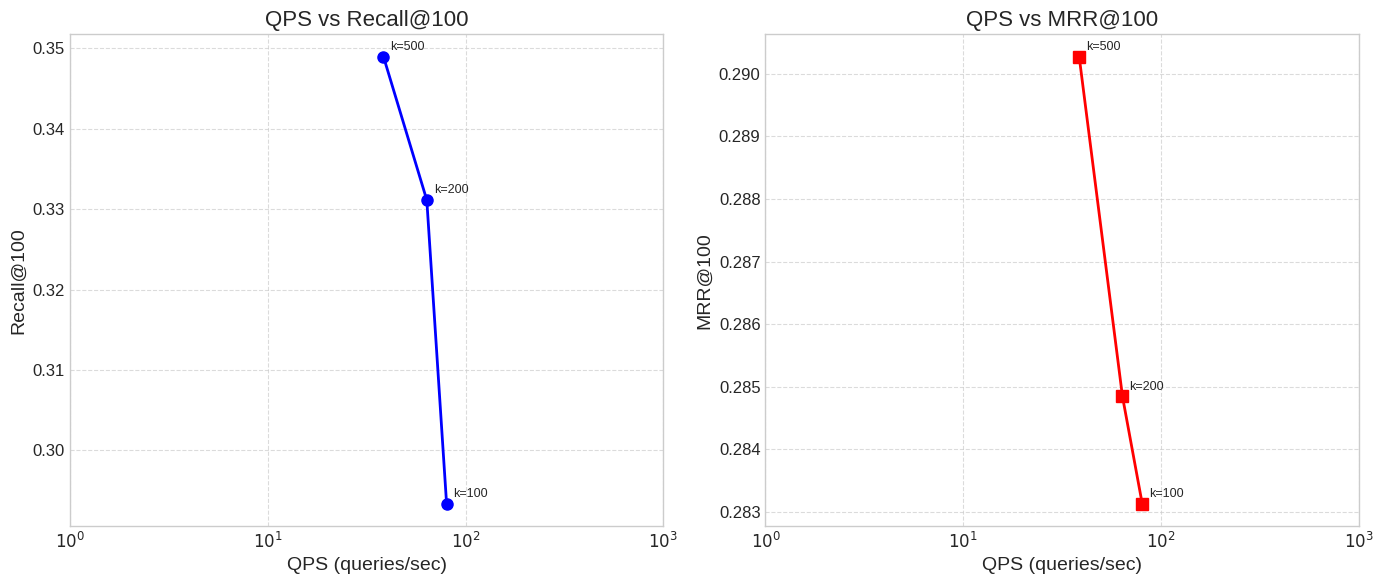

图片已保存为 '/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.png'


In [13]:
# plot

plot_qps_metrics("/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.csv",
                 topk=100,
                 retrieval_nprobe_query=4,
                 retrieval_initial_filter_k_list=[100, 200, 500])

## Fiqa

In [ ]:
# Run One wrapper

bash script/flat_multivector/run_dessert_flat.sh chenyifeng fiqa

In [ ]:
# plot

plot_qps_metrics("/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.csv",
                 topk=100,
                 retrieval_nprobe_query=4,
                 retrieval_initial_filter_k_list=[100, 200, 500])